In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from quantum_logical.operators import selective_destroy
from scipy.optimize import curve_fit

<p align="center"> Declaring the initilization parameters of the experiment

In [2]:
# generating parameters and creating initial state
T1 = 16
T2 = 8
N = 5
dim = 2
trotter_dt = .02
psi0 = qt.tensor((qt.basis(dim, 1)).unit(), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
# psi0 = qt.basis(dim, 1)
rho0 = psi0 * psi0.dag()
amp_damp_channel = AmplitudeDamping(T1, num_qubits=N, hilbert_space_dim=dim)
phase_damp_channel = PhaseDamping(T1, T2, num_qubits=N, hilbert_space_dim=dim)
trotter = TrotterGroup(
    continuous_operators=[amp_damp_channel, phase_damp_channel],
    trotter_dt=trotter_dt,
)


# qt.Qobj(amp_damp_channel._create_single_qubit_operators(T1=1)[1])
# identity = qt.qeye(dim ** N)

<p align="center"> Create all of the required gates

<p align="center"><img src = "https://i.sstatic.net/mbg8X.jpg">

In [3]:
# remake the gates
cnot1 = qt.Qobj(qt.tensor(qt.Qobj([[1,0,0,0], [0,1,0,0], [0,0,0,1], [0,0,1,0]]), qt.qeye(dim), qt.qeye(dim), qt.qeye(dim)).full())
mat_cnot2 = np.zeros(shape = (dim ** 3, dim ** 3))
for i in range(dim ** 3): # bad loop are you stupid?
    for j in range(dim ** 3):
        if i == j  and i not in [7, 6, 5, 4]:
            mat_cnot2[i, j] = 1

mat_cnot2[7, 6] = mat_cnot2[6, 7] = mat_cnot2[5, 4] = mat_cnot2[4, 5] = 1

cnot2 = qt.Qobj(qt.tensor(qt.Qobj(mat_cnot2), qt.qeye(dim), qt.qeye(dim)).full())

mat_cnot3 = np.zeros(shape = (dim ** 4, dim ** 4))
for i in range(dim ** 4):
    if i not in [15, 14, 13, 12, 11, 10, 9, 8]:
        mat_cnot3[i, i] = 1 

mat_cnot3[15, 14] = mat_cnot3[14, 15] = mat_cnot3[13, 12] = mat_cnot3[12, 13] = 1
mat_cnot3[11, 10] = mat_cnot3[10, 11] = mat_cnot3[9, 8] = mat_cnot3[8, 9] = 1

cnot3 = qt.Qobj(qt.tensor(qt.Qobj(mat_cnot3), qt.qeye(dim)).full())

cnot4 = qt.Qobj(qt.tensor(qt.qeye(dim), qt.Qobj(mat_cnot2), qt.qeye(dim)).full())

cnot5 = qt.Qobj(qt.tensor(qt.qeye(dim), qt.Qobj(mat_cnot3)).full())

cnot6 = qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.Qobj(mat_cnot2)).full())

x_gate = qt.Qobj([[0, 1], [1, 0]])

<p align="center">Encoding the initial state 

In [4]:
rho0 = qt.Qobj(rho0.full())
rho_encoded = cnot2.dag() * cnot1.dag() * rho0 * cnot1 * cnot2
states = []
states.append(rho_encoded)
fidelity_list_one_cycle = []

# need to trace out the ancilla from the states that way you can actually see the results properly 

<p align = "center">Applying the error channels

In [5]:
gate_order = cnot6 * cnot5 * cnot4 * cnot3
error_dur = 0
# error_states = trotter.apply(rho_encoded, duration=error_dur, discrete_unitary=qt.qeye(dim ** N))
# states.extend(error_states)
# fidelity_list_one_cycle.append(qt.fidelity(error_states[-1], rho_encoded))
cnot_time = 40
# pre_measure_state = trotter.apply(error_states[-1], duration=cnot_time, discrete_unitary=gate_order)
pre_measure_state = trotter.apply(rho_encoded, duration=cnot_time, discrete_unitary=gate_order)
states.extend(pre_measure_state)
fidelity_list_one_cycle.append(qt.fidelity(pre_measure_state[-1], rho_encoded))


final_state = pre_measure_state[-1]

<p align = "center">Create the measurement operators

In [6]:
projection_op = [qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag()))).full()),
                qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag()))).full()), 
                qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag()))).full()),
                qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag()))).full())
]

In [7]:
r00 = qt.tensor(qt.qeye(dim ** N))
r01 = qt.Qobj((qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim ** 3))).full())
r10 = qt.Qobj((qt.tensor(x_gate, qt.qeye(dim ** 4))).full())
r11 = qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.qeye(dim ** 2))).full())

In [8]:
# overall correction operator
correction_op = (r00 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag())).full()) +
                 r01 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag())).full()) +
                 r10 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())).full()) +
                 r11 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag())).full())
)

In [9]:
measurement_dur = 80
# measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=correction_op)
states.extend(measurement)
fidelity_list_one_cycle.append(qt.fidelity(measurement[-1], rho_encoded))
# final_state = measurement[-1]

In [10]:
# applying the recovery gate 

In [11]:
# rho_new = projection_op[0].dag() * final_state * projection_op[0] + projection_op[1].dag() * final_state * projection_op[1] + projection_op[2].dag() * final_state * projection_op[2] + projection_op[3].dag() * final_state * projection_op[3]
rho_1 = qt.tensor(qt.qeye(dim ** N)).dag() * projection_op[0].dag() * final_state * projection_op[0] * qt.tensor(qt.qeye(dim ** N))
rho_2 = qt.Qobj((qt.tensor(x_gate, qt.qeye(dim ** 4)).dag()).full()) * projection_op[1].dag() * final_state * projection_op[1] * qt.Qobj((qt.tensor(x_gate, qt.qeye(dim ** 4))).full())
rho_3 = qt.Qobj((qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim ** 3)).dag()).full()) * projection_op[2].dag() * final_state * projection_op[2] * qt.Qobj((qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim ** 3))).full())
rho_4 = qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.qeye(dim ** 2)).dag()).full()) * projection_op[3].dag() * final_state * projection_op[3] * qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.qeye(dim ** 2))).full())
rho_new = rho_1 + rho_2 + rho_3 + rho_4
rho_new = rho_new / np.real(np.trace(rho_new.full()))
# rho_new = rho_1
# states.append(rho_new)
# fidelity_list_one_cycle.append(qt.fidelity(rho_new, rho_encoded))

In [12]:
# the cell above does not make sense 


Need to implement the correction code because right now this makes no sense 

In [13]:
# add a relaxation period to see what it looks like 
relax_dur = 350
relaxation = trotter.apply(measurement[-1], duration=relax_dur, discrete_unitary=qt.qeye(dim ** N))
states.extend(relaxation)
fidelity_list_one_cycle.append(qt.fidelity(relaxation[-1], rho_encoded))

In [14]:
total_cirquit_duration = cnot_time + error_dur + relax_dur + measurement_dur
time_list = np.linspace(0, total_cirquit_duration, len(states))

Find a way to plot this and talk to Evan about the results because right now this does not make much sense to me 

In [15]:
fidelity_list_one_cycle

[0.47245513715068427, 0.11319747933996942, 0.00018263489531503642]

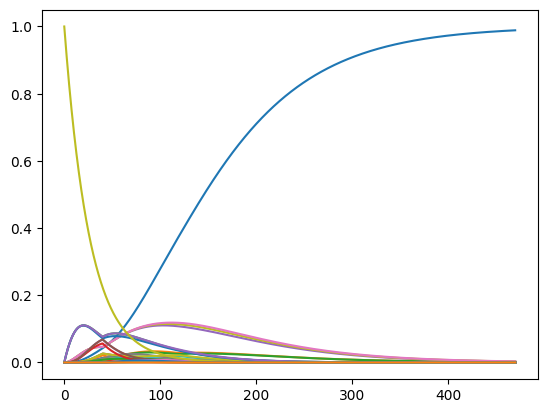

In [16]:
# label these plots with the states
fig, ax = plt.subplots()
for i in range(dim ** N):
    datas = []
    for j in range(len(states)):
        # print(np.real(states[j][i, i]))
        datas.append(np.real(states[j][i, i]))    
    ax.plot(time_list, datas)
# datas = []
# for i in range(len(states)- 12000):
#     print(np.real(states[i][0, 0])) 
#     datas.append(np.real(states[i][0, 0]))

# ax.plot(time_list[0:38032], datas)

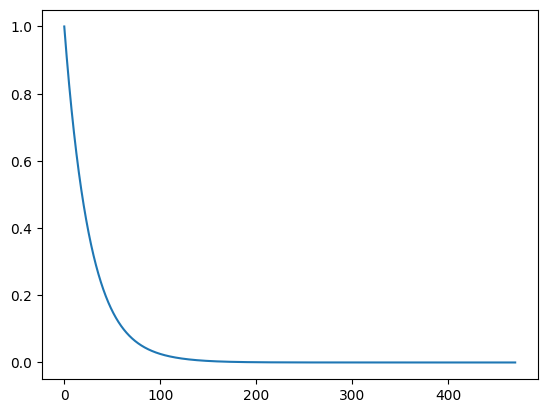

In [17]:
# label these plots with the states
fig, ax = plt.subplots()
datas = []
for j in range(len(states)):
    # print(np.real(states[j][i, i]))
    datas.append(np.real(states[j][28, 28]))    
ax.plot(time_list, datas)

In [18]:
qt.fidelity(rho_encoded, states[-1])

0.00018014273244233996

can you trace out the ancillas easily? 0.9947646906639211

how much of an improvement is there between stabilizer rounds?

In [18]:
def stabilizer(initial_state, rho_encoded_original):
    fidelity_list = []
    states = []
    
    fidelity_list.append(qt.fidelity(initial_state, rho_encoded_original))
    gate_order = cnot6 * cnot5 * cnot4 * cnot3
    error_dur = 40
    error_states = trotter.apply(initial_state, duration=error_dur, discrete_unitary=qt.qeye(dim ** N))
    states.extend(error_states)
    fidelity_list.append(qt.fidelity(error_states[-1], rho_encoded_original))
    cnot_time = 40
    pre_measure_state = trotter.apply(error_states[-1], duration=cnot_time, discrete_unitary=gate_order)
    states.extend(pre_measure_state)
    fidelity_list.append(qt.fidelity(pre_measure_state[-1], rho_encoded_original))


    final_state = pre_measure_state[-1]


    projection_op = [qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag()))).full()),
                qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag()))).full()), 
                qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag()))).full()),
                qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag()))).full())
    ]

    # measurement stage
    measurement_dur = 0
    # measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
    # states.extend(measurement)
    # fidelity_list.append(qt.fidelity(measurement[-1], rho_encoded_original))

    
    # rho_new = projection_op[0].dag() * final_state * projection_op[0] + projection_op[1].dag() * final_state * projection_op[1] + projection_op[2].dag() * final_state * projection_op[2] + projection_op[3].dag() * final_state * projection_op[3]
    rho_1 = qt.tensor(qt.qeye(dim ** N)).dag() * projection_op[0].dag() * final_state * projection_op[0] * qt.tensor(qt.qeye(dim ** N))
    rho_2 = qt.Qobj((qt.tensor(x_gate, qt.qeye(dim ** 4)).dag()).full()) * projection_op[1].dag() * final_state * projection_op[1] * qt.Qobj((qt.tensor(x_gate, qt.qeye(dim ** 4))).full())
    rho_3 = qt.Qobj((qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim ** 3)).dag()).full()) * projection_op[2].dag() * final_state * projection_op[2] * qt.Qobj((qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim ** 3))).full())
    rho_4 = qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.qeye(dim ** 2)).dag()).full()) * projection_op[3].dag() * final_state * projection_op[3] * qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.qeye(dim ** 2))).full())
    rho_new = rho_1 + rho_2 + rho_3 + rho_4
    rho_new = rho_new / np.real(np.trace(rho_new.full()))
    # rho_new = rho_1
    states.append(rho_new)
    fidelity_list.append(qt.fidelity(rho_new, rho_encoded_original))

    # add a relaxation period to see what it looks like 
    relax_dur = 200
    relaxation = trotter.apply(rho_new, duration=relax_dur, discrete_unitary=qt.qeye(dim ** N))
    states.extend(relaxation)
    fidelity_list.append(qt.fidelity(relaxation[-1], rho_encoded_original))

    return states, fidelity_list

In [19]:
rho_original = rho_encoded

In [20]:
# results_states = []
# results_fids = []
# a, b = stabilizer(initial_state=rho_encoded, rho_encoded_original=rho_original)
# results_states.extend(a)
# results_fids.extend(b)


In [21]:
# results_fids

In [22]:
# number of iterations
results_states = []
results_fids = []
iterations = 100
it_list = []
for i in range(iterations):
    it_list.append(i)
    a, b = stabilizer(initial_state=rho_encoded, rho_encoded_original=rho_original)
    results_states.extend(a)
    results_fids.extend(b)
    rho_encoded = results_states[-1]
results_fids.append(results_fids[-1])

In [23]:
results_fids

[1.0,
 0.9992502813670305,
 0.9985011248120906,
 0.9970044962510093,
 0.9985011248120906,
 0.9947646906639211,
 0.9947646906639211,
 0.9940190830595564,
 0.993274034218697,
 0.9917856111532809,
 0.993274034218697,
 0.9895605691674498,
 0.9895605691674498,
 0.9888195425031727,
 0.9880790703192933,
 0.986599787735578,
 0.9880790703192932,
 0.9843850495661404,
 0.9843850495661404,
 0.9836479030265086,
 0.9829113080606967,
 0.9814397712020471,
 0.9829113080606966,
 0.9792375644771846,
 0.9792375644771846,
 0.9785044635570402,
 0.9777719109456353,
 0.9763084490114787,
 0.9777719109456353,
 0.9741207571138782,
 0.9741207571138782,
 0.9733921614842592,
 0.9726641099532388,
 0.9712096375661704,
 0.9726641099532387,
 0.9690320633984121,
 0.9690320633984121,
 0.9683072806506399,
 0.9675830391485931,
 0.9661361782693371,
 0.9675830391485931,
 0.9639709448046266,
 0.9639709448046266,
 0.963250142837067,
 0.9625298789008758,
 0.9610909635210049,
 0.9625298789008759,
 0.9589399926336871,
 0.95893999

In [24]:
int(len(results_fids) / 6)

100

In [26]:
fidelity_finals = []
for i in range(int((len(results_fids) / 6))):
    if i == 0:
        fidelity_finals.append(results_fids[i * 6 + 6])
    else:
        fidelity_finals.append(results_fids[i * 6 + 5])

In [27]:
fidelity_finals

[0.9947646906639211,
 0.9895605691674498,
 0.9843850495661404,
 0.9792375644771846,
 0.9741207571138782,
 0.9690320633984121,
 0.9639709448046266,
 0.9589399926336871,
 0.9539366813907776,
 0.9489604999965621,
 0.9440139915786253,
 0.9390946524509853,
 0.9342019986299782,
 0.9293385230894343,
 0.924501760192409,
 0.9196912518031566,
 0.9149094443777098,
 0.9101538940085999,
 0.9054241679750193,
 0.9007226642835863,
 0.8960469765327682,
 0.8913966963238449,
 0.8867741767495537,
 0.8821770330383557,
 0.8776048806028693,
 0.8730600257382013,
 0.8685401206275957,
 0.8640448035501356,
 0.8595763374405383,
 0.8551323959938014,
 0.8507126397708792,
 0.8463192865095388,
 0.841950046301398,
 0.837604601185663,
 0.8332851270442322,
 0.8289893553447353,
 0.8247169889500594,
 0.8204701600961254,
 0.8162466360829904,
 0.8120461399283303,
 0.8078707634691045,
 0.803718295229407,
 0.7995884776608443,
 0.7954833604570938,
 0.7914007674053477,
 0.7873404598507063,
 0.7833044484985604,
 0.77929057819306

do this same thing for an idle qubit in order to get a proper T1 assuming no correction and then fit it to a line 

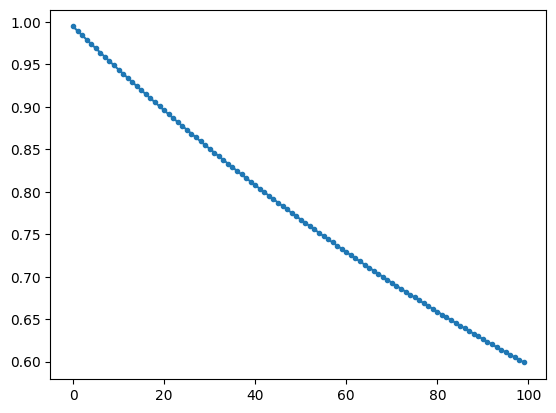

In [28]:
fig, ax = plt.subplots()
ax.plot(it_list, fidelity_finals, marker = ".")

In [29]:
time_list = np.linspace(0, iterations * total_cirquit_duration, len(results_states))

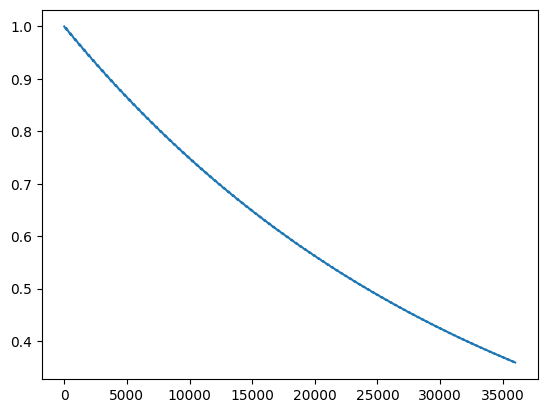

In [30]:
# label these plots with the states
fig, ax = plt.subplots()
datas = []
for j in range(len(results_states)):
    # print(np.real(states[j][i, i]))
    datas.append(np.real(results_states[j][28, 28]))    
ax.plot(time_list, datas)